In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = sns.load_dataset('tips')

In [8]:
df


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


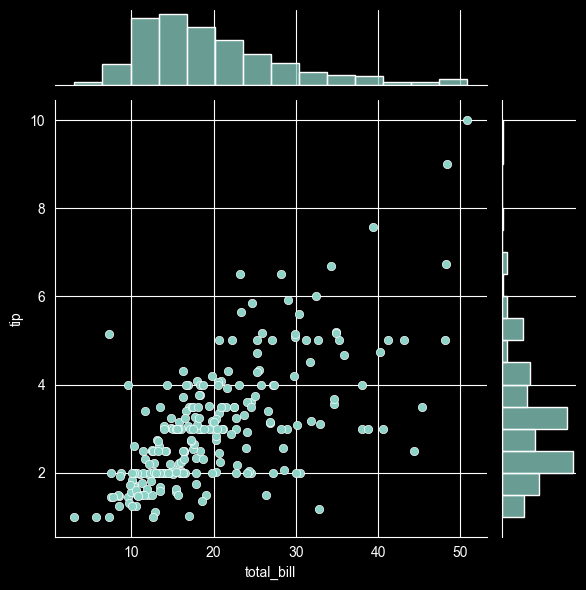

In [16]:
sns.jointplot(data=df, x="total_bill", y="tip")
log_tip = np.log(df['tip'])
log_bill = np.log(df['total_bill'])

In [17]:
from scipy.stats import pearsonr

In [18]:
pearsonr(log_tip, log_bill)

PearsonRResult(statistic=np.float64(0.6795702560274505), pvalue=np.float64(2.0794565165372116e-34))

<Axes: xlabel='size', ylabel='tip'>

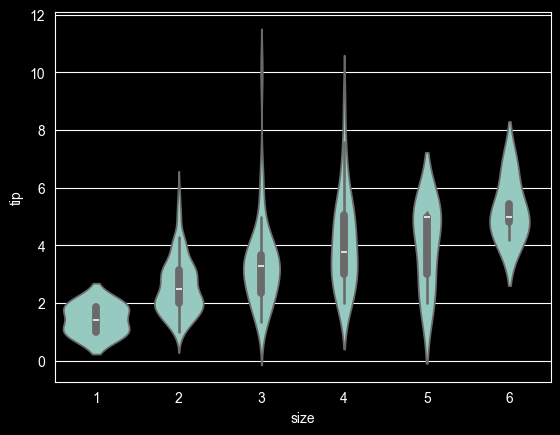

In [19]:
sns.violinplot(data=df, x="size", y="tip")

In [20]:
from scipy.stats import kendalltau
kendalltau(log_tip, log_bill)


SignificanceResult(statistic=np.float64(0.517180972142381), pvalue=np.float64(2.445572848021409e-32))

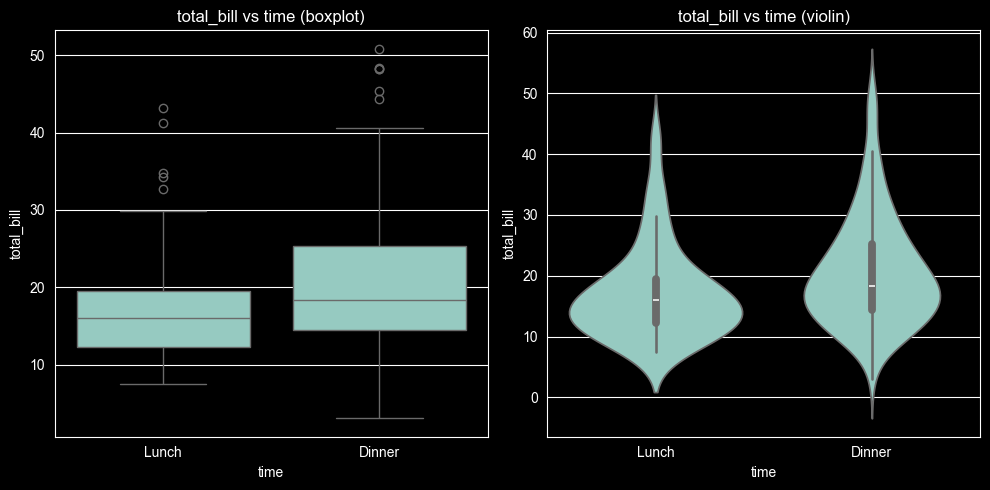

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x='time', y='total_bill', ax=axes[0])
axes[0].set_title('total_bill vs time (boxplot)')

sns.violinplot(data=df, x='time', y='total_bill', ax=axes[1])
axes[1].set_title('total_bill vs time (violin)')

plt.tight_layout()
plt.show()

In [25]:
df['bill_category'] = pd.cut(
    df['total_bill'],
    bins=[0, 10, 20, 30, 50],
    labels=['low', 'medium', 'high', 'very high']
)

In [26]:
print(df['total_bill'].quantile([0, 0.25, 0.5, 0.75, 1.0]))


0.00     3.0700
0.25    13.3475
0.50    17.7950
0.75    24.1275
1.00    50.8100
Name: total_bill, dtype: float64
